# **HW3: Linear Regression Analysis**

### **TODO: Martin Jesus Colmenero Jr**


**Attention: This assignment is to be completed individually. Group work is not permitted.**

# **Part 1**

Imagine you are a Data Scientist working at Uber Eats. Your manager has assigned you a critical task: improving the delivery time estimation feature in the app. This feature helps customers know when to expect their food and allows the company to better manage deliveries.

To tackle this problem, you'll be working with the Food Delivery Times dataset from Kaggle, which contains historical delivery data including factors like distance, weather conditions, and traffic levels. Your goal is to predict how long each delivery will take.

Since this is a prediction task where we need to estimate delivery times (a continuous numerical value), you'll start by implementing Linear Regression. This will serve as your first step in building a delivery time prediction model.



#### **About the Dataset**

The Food Delivery Time Prediction dataset simulates real-world delivery data. Published on Kaggle in 2024, it contains 1,000 delivery records from a food delivery service. Each record includes important delivery information such as distance traveled, traffic conditions, weather, and the actual delivery time. You'll use this dataset to develop a model that predicts delivery duration based on these various factors.

This dataset contains 1000 datapoints (examples of deliveries) and each contains information about a delivery, like the weather in which the delivery was made.


**Key Features:**

`Order_ID`: Unique identifier for each order.

`Distance_km`: The delivery distance in kilometers.

`Weather`: Weather conditions during the delivery, including Clear, Rainy, Snowy, Foggy, and Windy.

`Traffic_Level`: Traffic conditions categorized as Low, Medium, or High.

`Time_of_Day`: The time when the delivery took place, categorized as Morning, Afternoon, Evening, or Night.

`Vehicle_Type`: Type of vehicle used for delivery, including Bike, Scooter, and Car.

`Preparation_Time_min`: The time required to prepare the order, measured in minutes.

`Courier_Experience_yrs`: Experience of the courier in years.

`Delivery_Time_min`: The total delivery time in minutes (target variable).


In [40]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## **Question 1: Load and Explore the data**



In [3]:
# Write your code here
delivery_time_df = pd.read_csv('Food_Delivery_Times.csv', index_col=False)

#### **Exploratory Data Analysis:**

* Review the output of the following EDA operations and review to get a better understanding of what your data looks like.
* Use **at least four** built-in methods from Pandas to explore the dataset. The choice is yours, but focus on the most important aspects that provide a quick understanding of the data.

In [4]:
# Method 1
delivery_time_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [5]:
# Method 2
delivery_time_df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [6]:
# Method 3
delivery_time_df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
# Method 4
delivery_time_df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


# **Part 2:**

In this part of the homework, you will perform a closer analysis of the data to gain insights and familiarize yourself with working in Python using libraries such as NumPy and Pandas. The goal is to extract useful information and make simple observations.

## **Question 2**

* Explore Weather Patterns: Find all unique weather conditions in our dataset and count how often each occurs. Hint: Use the pandas `value_counts()` function.

* Similarly, analyze the distribution of vehicle types used for deliveries.

* Finally, look at the results and tell us what you notice. Is there anything surprising to you?

In [8]:
# Write your code here
unique_weather_conditions = delivery_time_df['Weather'].value_counts()
print(unique_weather_conditions)

Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64


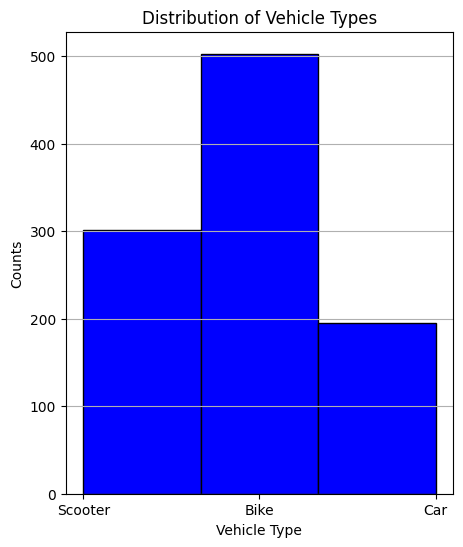

In [19]:
# Write your code here
plt.figure(figsize=(5, 6))
plt.hist(delivery_time_df['Vehicle_Type'], bins=3, color='blue', edgecolor='black')
plt.title('Distribution of Vehicle Types')
plt.xlabel('Vehicle Type')
plt.ylabel('Counts')
plt.grid(True, axis='y')
plt.show()

**WRITE YOUR ANSWER HERE: A majority of the deliveries are made when the weather is clear and most delivery drivers use a bike to make deliveries.**

For example: It is interesting to see that there are more delivery bikes than cars.

In [ ]:
# Write your code here
# A majority of the deliveries are made when the weather is clear and most delivery drivers use a bike to make deliveries.

# **Part 3:**

## **Question 3: Establishing a Baseline Prediction**
As a Data Scientist at Uber Eats, it's essential to establish a simple benchmark before developing complex models. A common baseline approach is to predict the average delivery time for every order, regardless of the input features.

Your task is to complete the `create_benchmark()` function below, which should return a NumPy array filled with the mean delivery time. Then, calculate and print the Root Mean Squared Error (RMSE) and R² score using scikit-learn's metrics module.

Finally, provide a brief explanation (2-3 sentences) of why the R² score is 0.0 in this scenario. Consider what R² represents and why always predicting the mean leads to this outcome.

In [25]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def create_benchmark(df):
    """Returns a NumPy array where every prediction is the mean delivery time."""
    # Write your code here
    average_delivery_time = df['Delivery_Time_min'].mean()
    yhat_equal_ybar = np.array([average_delivery_time for _ in range(df.shape[0])])
    return yhat_equal_ybar

def evaluate_baseline(df):
    """Computes RMSE and R² for the benchmark model."""

    # Write your code here
    y = df['Delivery_Time_min'].values
    yhat = create_benchmark(df)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    r2 = r2_score(y, yhat)


    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")

# Call evaluate the baseline model
evaluate_baseline(delivery_time_df)

RMSE: 22.06
R² Score: 0.00


**WRITE HERE YOU ANSWER HERE: The R^2 is a measure how well the independent variables/features predict the dependent/target variable/features as a ratio of the variation of the (y) explained by the feature variables to the the total variation in (y). The R^2 = 0 means that none of the feature varibles explain the target variable, which makes sense since we're only capturing the average delivery for all deliveries.**

*Sample answer: The R² score measures how well a model explains the variance in the actual data compared to simply predicting the mean. Since our benchmark model always predicts the mean delivery time, it does not capture any variance in the data. As a result, the R² score is 0.0, indicating that our model provides no improvement over the simplest possible prediction.*

## **Question 4: Implementing a Simple Linear Regression Model**

Before training a Linear Regression model, we need to handle missing values, as the algorithm does not support NaN values.

Your tasks:

1. Handle missing values by filling them with the most appropriate statistic:
    * For categorical columns, replace missing values with the mode (most frequent value).
    * For numerical columns, replace missing values with the mean.
2. Implement and train a Linear Regression model using `scikit-learn` `LinearRegression` estimator.
3. Evaluate the model by computing the Root Mean Squared Error (RMSE) and R² score.

**Note:** If modifying individual columns (e.g., df['Column'].fillna(value, inplace=True)), `inplace=True` can trigger chained assignment warnings, which is why I generally recommend avoiding it. If you decide to implement your solution as such, avoid using `inplace=True` parameter to prevent chained assignment warnings. Instead, update the dataframe properly. When modifying the entire DataFrame at once, on the other hand, such as using `df.fillna({...}, inplace=True)`, it's typically safe and doesn't cause warnings because it's applied at the DataFrame level, not through chained assignment.

In [38]:
# Write your code for #1 here
delivery_time_df.fillna({'Courier_Experience_yrs':delivery_time_df['Courier_Experience_yrs'].mean()}, inplace=True)
delivery_time_df.fillna({'Weather':delivery_time_df['Weather'].mode().iloc[0]}, inplace=True)
delivery_time_df.fillna({'Traffic_Level':delivery_time_df['Traffic_Level'].mode().iloc[0]}, inplace=True)
delivery_time_df.fillna({'Time_of_Day':delivery_time_df['Time_of_Day'].mode().iloc[0]}, inplace=True)

In [39]:
# Check your work to see if you successfully filled missing values
delivery_time_df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


Implement a Linear Regression model to predict delivery time based on the delivery distance (in kilometers).


Use scikit-learn's LinearRegression estimator to train a model where:
* Feature (X): `Distance_km`
* Target (y): `Delivery_Time_min`
* Train the model using the given dataset.
* Predict delivery times using the trained model.
* Evaluate the model's performance using Root Mean Squared Error (RMSE) and R² score.

Ensure your implementation follows best practices, including proper data preparation before training.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# write your code here
X = delivery_time_df['Distance_km'].values.reshape(-1, 1)
y = delivery_time_df['Delivery_Time_min'].values.reshape(-1, 1)

linear_model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8,random_state=42)
linear_model.fit(X_train, y_train)

yhat = linear_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, yhat))
r2 = r2_score(y_test, yhat)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 12.58
R² Score: 0.65


* Create an appropriate plot that shows both your data points and the linear regression line using matplotlib.

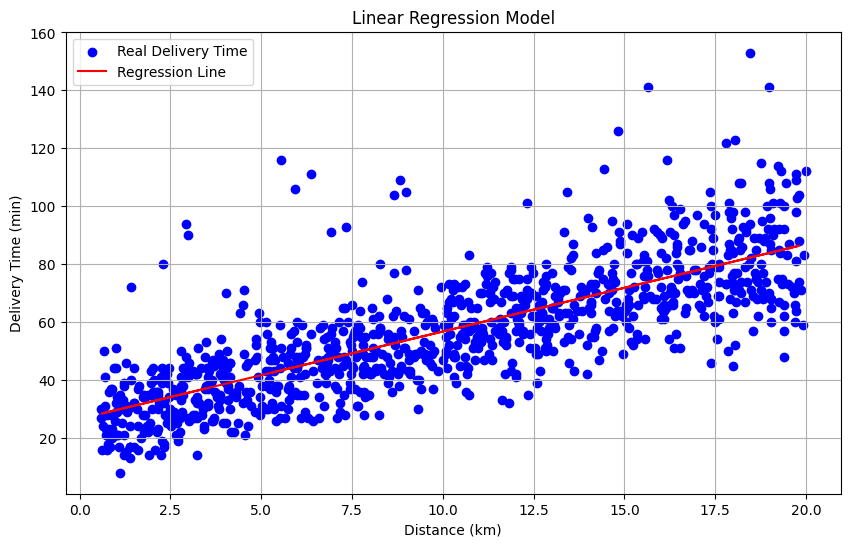

In [51]:
# Write your code here
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', label='Real Delivery Time')
plt.plot(X_test, yhat, color='red', label='Regression Line')
plt.title('Linear Regression Model')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')
plt.legend()
plt.grid()
plt.show()

Scatter plots show relationships between two variables:

* The x-axis (horizontal) typically represents the independent variable (predictor).
* The y-axis (vertical) represents the dependent variable (outcome).
Logical Interpretation:


## **Question 5:**

* Create a scatter plot to explore the relationship between preparation time and delivery distance. Use matplotlib to visualize how these two features relate to each other.


* Preparation_Time_min is the time taken to prepare the order.
* Distance_km is the distance traveled for delivery.

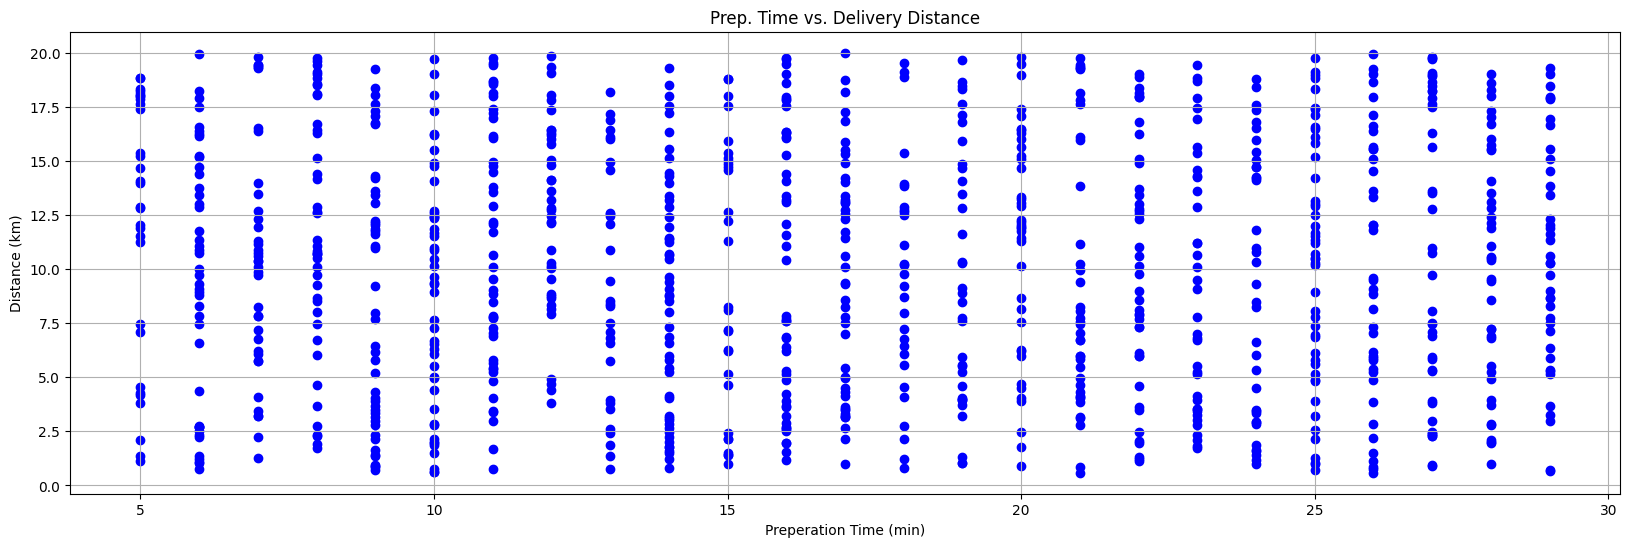

In [59]:
# Write your code here
plt.figure(figsize=(20,6))
plt.scatter(delivery_time_df['Preparation_Time_min'], delivery_time_df['Distance_km'], color='blue')
plt.title('Prep. Time vs. Delivery Distance')
plt.xlabel('Preperation Time (min)')
plt.ylabel('Distance (km)')
plt.grid()
plt.show()

* Would you use both of this features at the same time as features to feed into a Linear Regression model?

**WRITE YOUR ANSWER HERE: Based on the scatter plot, I would include both features since they have no to low correlation with each other which allows us to see how these features individually affect the target feature. Which satisfies the multicollinearity assumption.**

## **Question 6: Create a Multi-Linear Regression Model**

Expand your linear regression model by incorporating both delivery distance and preparation time as predictive features. While advanced feature engineering could improve model performance, this step will help us understand whether adding an extra variable enhances our ability to predict delivery times.

* Train a multiple linear regression model using both Distance_km and Preparation_Time_min as features.
* Evaluate the model using Root Mean Squared Error (RMSE) and R² score.

In [63]:
# Write your code here
multi_lin_model = LinearRegression()

X = delivery_time_df[['Distance_km', 'Preparation_Time_min']]
y = delivery_time_df['Delivery_Time_min']

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

multi_lin_model.fit(X_train, y_train)
yhat = multi_lin_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, yhat))
r2 = r2_score(y_test, yhat)


print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 12.17
R² Score: 0.70


## **Question 7: 3D Visualization of the Regression Model**

Create a three-dimensional plot to visualize the relationship between the two predictor variables (Distance and Preparation Time) and the target variable (Delivery Time).

Your visualization should include:

* Actual data points representing observed values.
* The prediction plane from the multiple linear regression model, showing how the model fits the data across both feature dimensions.
* Use the provided code structure and complete it to generate this 3D visualization.

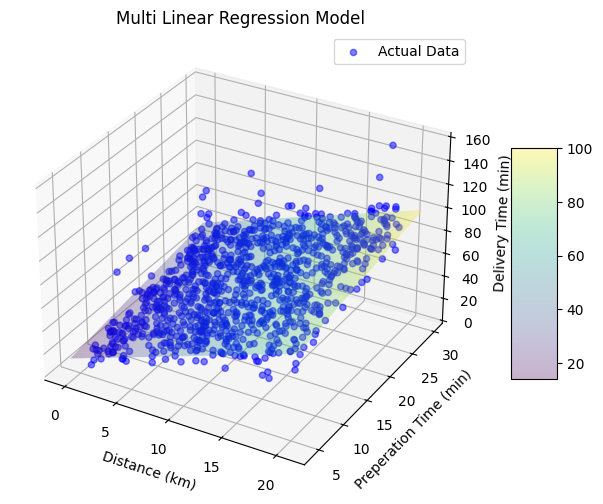

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create the figure
# write your code here
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# Define actual data points
#write your code here
X = delivery_time_df[['Distance_km', 'Preparation_Time_min']].values.reshape(-1, 2)
y = delivery_time_df['Delivery_Time_min']

# Plot actual data points
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', alpha=0.5, label='Actual Data')

# Create meshgrid for prediction surface
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))

# Generate predictions for the surface
mesh_X = np.column_stack((xx1.ravel(), xx2.ravel()))
mesh_X_df = pd.DataFrame(mesh_X, columns=['Distance_km', 'Preparation_Time_min'])
Z = multi_lin_model.predict(mesh_X_df)
Z = Z.reshape(xx1.shape)

# Plot prediction surface
surf = ax.plot_surface(xx1, xx2, Z, cmap='viridis', alpha=0.3)

# Set labels
#write your code here
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Preperation Time (min)')
ax.set_zlabel('Delivery Time (min)')
ax.set_title('Multi Linear Regression Model')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.legend()
plt.show()

## **Question 8**
* Analyze and compare the performance of your two linear regression models. Use the RMSE and R² values you calculated to discuss which model performs better at predicting delivery times and explain why this might be the case.

**WRITE YOUR ANSWER HERE: Based on the R^2, the multi linear regression model better predicts the target feature than the simple liner regression since its score was greater which were (0.65) and (0.70), respectively. Addtionally, the RMSE for the multi linear regression model was lower than the simple linear regression model, (12.58) and (12.17) respectively. Given these results, the multi linear regression is better at predicting delivery times since its including more features that help predict the target feature unlike the simple linear regression who's slope coefficient is likely biased due to a lack of features.**

* Consider why in the 3D visualization of the Multi-Linear Regression model the predicted values are not represented in a line but in a 2D plane.

**WRITE YOUR ANSWER HERE: In the 3D visualizaiton, we see predicted predicted values in a 2D plance because they are being influenced by both features in the model. It's capturing effect of both distance and preportaion time on delivery time**